# Modelos de Lenguaje de Markov
## N-gramas, Suavizado de Laplace, Generación de Texto y Perplejidad

En este notebook exploraremos cómo construir un **modelo de lenguaje basado en cadenas de Markov** aplicado a letras de canciones.

Cubriremos:
1. Descompresión del corpus desde un fichero `.zip`
2. Carga y etiquetado del corpus con `<SOC>`, `</SOC>`, `<EOL>`
3. Tokenización
4. Visualización del corpus
5. Estimación de n-gramas (MLE)
6. Suavizado de Laplace
7. **Generación de frases muestreando n-gramas**
8. Log-verosimilitud de una frase
9. Perplejidad

---
## 0. Instalación de dependencias

In [4]:
%pip install nltk wordcloud matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


---
## 1. Importaciones y descarga de recursos NLTK

In [5]:
import os
import re
import zipfile
import random
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.lm import Laplace, MLE
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.tokenize import word_tokenize
from nltk.util import ngrams as nltk_ngrams
from nltk.corpus import stopwords
from wordcloud import WordCloud

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print('✅ Todo listo.')

✅ Todo listo.


---
## 2. Descompresión del corpus

> Modifica `ZIP_PATH` con la ruta a tu fichero zip.

In [6]:
ZIP_PATH    = "andres_calamaro_lyrics.zip"
EXTRACT_DIR = "Andrés Calamaro"

def extract_zip(zip_path, extract_to):
    os.makedirs(extract_to, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_to)
        n = len(z.namelist())
    print(f"✅ Extraídos {n} ficheros en '{extract_to}/'")

extract_zip(ZIP_PATH, EXTRACT_DIR)

✅ Extraídos 605 ficheros en 'Andrés Calamaro/'


---
## 3. Carga y etiquetado del corpus

| Etiqueta | Significado |
|---|---|
| `<soc>` | Inicio de canción (*Start Of Composition*) |
| `</soc>` | Fin de canción |
| `<eol>` | Fin de verso (*End Of Line*) |

In [7]:
def tag_corpus(text):
    lines = text.splitlines()
    tagged_lines = [line + " <EOL>" for line in lines if line.strip()]
    return "<SOC> " + " ".join(tagged_lines) + " </SOC>"

def load_corpus(folder):
    texts = []
    for root, _, files in os.walk(folder):
        for filename in sorted(files):
            if filename.endswith(".txt"):
                with open(os.path.join(root, filename), encoding="utf-8") as f:
                    texts.append(tag_corpus(f.read()))
    return texts

raw_texts = load_corpus(EXTRACT_DIR)
print(f"Canciones cargadas: {len(raw_texts)}")
print(f"\nEjemplo — primeros 300 caracteres:")
print(raw_texts[0][:300])

Canciones cargadas: 1208

Ejemplo — primeros 300 caracteres:
<SOC> En el balcón <EOL> Donde pega más el sol <EOL> Mirando pasar <EOL> A los pájaros volar <EOL> No quiero saber <EOL> De dónde vienen volando <EOL> No quiero saber <EOL> A dónde van <EOL> Mirando pasar <EOL> Como tal al motor del mal <EOL> Hoy puedo seguir <EOL> Normal sin pensar en nada <EOL> ¡N


---
## 4. Tokenización

Usamos **placeholders temporales** para proteger las etiquetas `<soc>`, `</soc>`, `<eol>` de ser fragmentadas por el tokenizador.

In [8]:
SPECIAL_TOKENS = {"<soc>", "</soc>", "<eol>"}

def clean_and_tokenize(text):
    text = text.lower()
    # Proteger etiquetas con placeholders antes de limpiar puntuación
    text = text.replace("<soc>",  "__SOC__")
    text = text.replace("</soc>", "__ESOC__")
    text = text.replace("<eol>",  "__EOL__")
    # Eliminar puntuación (ya no hay < > /)
    text = re.sub(r"[^\w\sáéíóúüñ]", "", text)
    tokens = word_tokenize(text, language="spanish")
    # Restaurar etiquetas
    tokens = [t.replace("__SOC__",  "<soc>")
               .replace("__ESOC__", "</soc>")
               .replace("__EOL__",  "<eol>") for t in tokens]
    return tokens

tokenized = [clean_and_tokenize(t) for t in raw_texts]

print("Tokens de la primera canción (primeros 20):")
print(tokenized[0][:20])

Tokens de la primera canción (primeros 20):
['<soc>', 'en', 'el', 'balcón', '<eol>', 'donde', 'pega', 'más', 'el', 'sol', '<eol>', 'mirando', 'pasar', '<eol>', 'a', 'los', 'pájaros', 'volar', '<eol>', 'no']


---
## 5. Visualización del Corpus

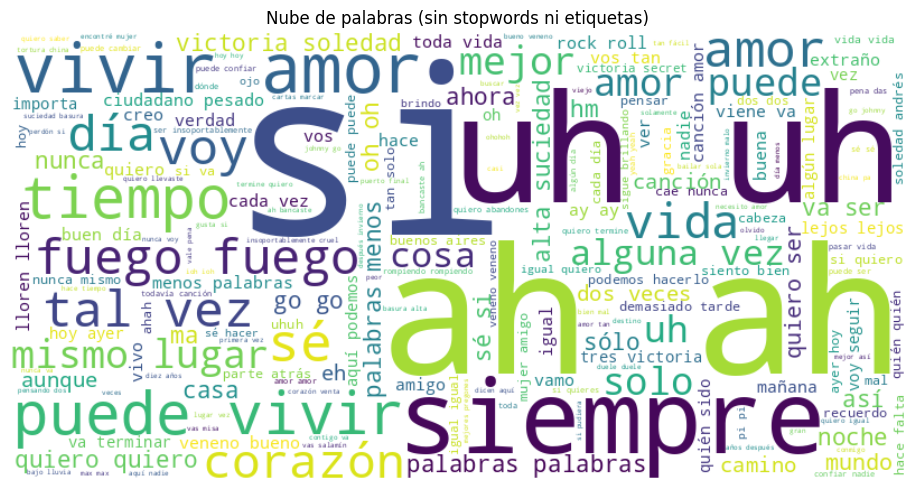

In [9]:
spanish_sw = set(stopwords.words('spanish'))
SKIP = SPECIAL_TOKENS | {"<s>", "</s>"}

all_tokens_viz = [
    w for song in tokenized
    for w in song
    if w not in SKIP and w not in spanish_sw
]

# ── Word cloud ────────────────────────────────────────────────────────────────
wc = WordCloud(width=800, height=400, background_color='white')
wc.generate(" ".join(all_tokens_viz))

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras (sin stopwords ni etiquetas)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_101483/3184086547.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bg, x='Frecuencia', y='Bigrama', palette='viridis')


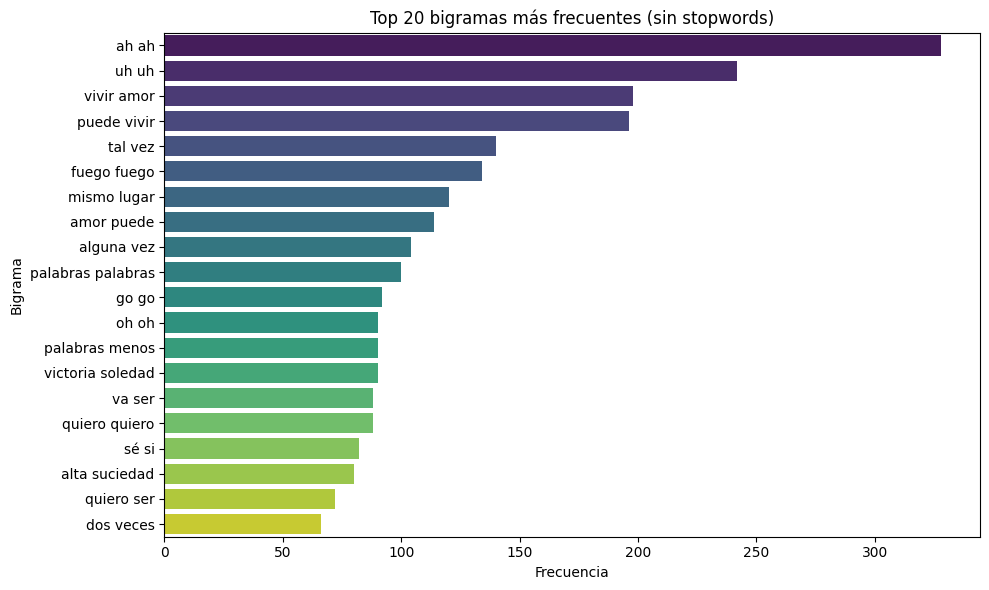

,Bigrama,Frecuencia
0,ah ah,328
1,uh uh,242
2,vivir amor,198
3,puede vivir,196
4,tal vez,140
5,fuego fuego,134
6,mismo lugar,120
7,amor puede,114
8,alguna vez,104
9,palabras palabras,100


In [10]:
# ── Top 20 bigramas ───────────────────────────────────────────────────────────
bigrams_viz  = list(nltk_ngrams(all_tokens_viz, 2))
bigram_freq  = Counter(bigrams_viz)
top_bigrams  = bigram_freq.most_common(20)

df_bg = pd.DataFrame(top_bigrams, columns=['Bigrama', 'Frecuencia'])
df_bg['Bigrama'] = df_bg['Bigrama'].apply(lambda x: f'{x[0]} {x[1]}')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_bg, x='Frecuencia', y='Bigrama', palette='viridis')
plt.title('Top 20 bigramas más frecuentes (sin stopwords)')
plt.tight_layout()
plt.show()

display(df_bg)

---
## 6. División train / test  (80 / 20)

In [11]:
split       = int(len(tokenized) * 0.8)
train_sents = tokenized[:split]
test_sents  = tokenized[split:]

print(f"Canciones de entrenamiento : {len(train_sents)}")
print(f"Canciones de test          : {len(test_sents)}")

Canciones de entrenamiento : 966
Canciones de test          : 242


---
## 7. Estimación de N-gramas (MLE)

$$P(w_i \mid w_{i-n+1}, \ldots, w_{i-1}) = \frac{C(w_{i-n+1}, \ldots, w_i)}{C(w_{i-n+1}, \ldots, w_{i-1})}$$

Problema: cualquier n-grama no visto recibe probabilidad **0**.

In [12]:
N = 2  # cambiar a 3 para trigramas

mle_train_data, mle_vocab = padded_everygram_pipeline(N, train_sents)
model_mle = MLE(N)
model_mle.fit(mle_train_data, mle_vocab)

print(f"Orden del modelo (N)  : {N}")
print(f"Tamaño del vocabulario: {len(model_mle.vocab)}")

word, context = "locura", ["bendita"]
print(f"\nP('{word}' | {context})  MLE     = {model_mle.score(word, context):.6f}")
print(f"P('{word}' | {context})  log₂MLE = {model_mle.logscore(word, context):.6f}")

Orden del modelo (N)  : 2
Tamaño del vocabulario: 9058

P('locura' | ['bendita'])  MLE     = 0.000000
P('locura' | ['bendita'])  log₂MLE = -inf


---
## 8. Suavizado de Laplace

$$P_{\text{Laplace}}(w \mid \text{ctx}) = \frac{C(\text{ctx},\, w) + 1}{C(\text{ctx}) + |V|}$$

Ningún n-grama tendrá probabilidad cero.

In [13]:
train_data, vocab = padded_everygram_pipeline(N, train_sents)
model = Laplace(N)
model.fit(train_data, vocab)

print(f"Modelo Laplace entrenado. Vocabulario: {len(model.vocab)} tokens")

print("\n--- N-grama visto ---")
word, context = "locura", ["bendita"]
print(f"P('{word}' | {context})  MLE     = {model_mle.score(word, context):.6f}")
print(f"P('{word}' | {context})  Laplace = {model.score(word, context):.6f}")

print("\n--- N-grama NO visto (palabra inventada) ---")
unseen = "xiloptrón"
print(f"P('{unseen}' | {context})  MLE     = {model_mle.score(unseen, context):.6f}")
print(f"P('{unseen}' | {context})  Laplace = {model.score(unseen, context):.6f}")

Modelo Laplace entrenado. Vocabulario: 9058 tokens

--- N-grama visto ---
P('locura' | ['bendita'])  MLE     = 0.000000
P('locura' | ['bendita'])  Laplace = 0.000110

--- N-grama NO visto (palabra inventada) ---
P('xiloptrón' | ['bendita'])  MLE     = 0.000000
P('xiloptrón' | ['bendita'])  Laplace = 0.000110


---
## 9. Generación de Frases Muestreando N-gramas

El proceso de generación es una **cadena de Markov**:

1. Partir de un contexto inicial `["<s>"]` (para bigramas) o una palabra semilla
2. En cada paso, obtener la distribución $P(w \mid \text{contexto})$ sobre el vocabulario
3. **Muestrear** el siguiente token según esa distribución
4. Añadirlo al contexto y repetir hasta `</s>` o longitud máxima

El parámetro **temperatura** $T$ controla la aleatoriedad aplicando $p_i \leftarrow p_i^{1/T}$ antes de normalizar:
- $T < 1$ → distribución más concentrada (texto más predecible)
- $T = 1$ → distribución original
- $T > 1$ → distribución más plana (texto más aleatorio)

> **Nota sobre eficiencia:** iterar todo el vocabulario en cada paso es correcto pero lento con vocabularios grandes. Para uso en producción se usaría una estructura de datos invertida (contexto → lista de continuaciones).

In [14]:
def generate_text(model, n, max_length=20, seed_token=None, temperature=1.0, random_state=None):
    if random_state is not None:
        random.seed(random_state)

    context   = ["<s>"] * (n - 1)
    generated = []

    if seed_token is not None:
        seed_lower = seed_token.lower()
        if seed_lower in model.vocab:
            generated.append(seed_lower)
            # Contexto deslizante: descartar <s> y añadir la semilla
            context = (context + [seed_lower])[-(n - 1):] if n > 1 else []
        else:
            print(f"  ⚠️ '{seed_token}' no está en el vocabulario.")

    for _ in range(max_length - len(generated)):  # FIX: descontar tokens ya generados
        ctx_tuple = tuple(context[-(n - 1):]) if n > 1 else ()

        candidates, weights = [], []
        for word in model.vocab:
            p = model.score(word, list(ctx_tuple))
            if p > 0:
                candidates.append(word)
                weights.append(p ** (1.0 / temperature))

        if not candidates:
            break

        total   = sum(weights)
        weights = [w / total for w in weights]
        next_word = random.choices(candidates, weights=weights, k=1)[0]

        if next_word == "</s>":
            break

        generated.append(next_word)
        context = (context + [next_word])[-(n - 1):] if n > 1 else []

    return generated

In [15]:
# ── Generación libre (sin semilla) ────────────────────────────────────────────
print("=" * 60)
print("GENERACIÓN LIBRE (sin semilla, temperatura = 1.0)")
print("=" * 60)

for i in range(5):
    tokens = generate_text(model, N, max_length=15, random_state=i)
    print(f"\nFrase {i+1}: {' '.join(tokens)}")

GENERACIÓN LIBRE (sin semilla, temperatura = 1.0)

Frase 1: gemelo danza soñaba persona letras brillando entrañables piratas mesa cirugía toro acabar culpable calenturas reconcilie

Frase 2: importante intactos llames lacas agaches divertir nacional evitamos pata sufrir conoció tysson desintegra pájaros chorizo

Frase 3: imperdible llovió confesándole adivinando desfile banco serena hiciste aguantan luchas pataleando dolor eduardo quemar película

Frase 4: dicen saca perejil vivirán lío llorar

Frase 5: gracias malherido villalicencio apurarme bonano sacrificios partidas décadas sacaste sonidos sirenas camiseta interesa ladrar aromas


In [16]:
# ── Efecto de la temperatura ──────────────────────────────────────────────────
print("=" * 60)
print("EFECTO DE LA TEMPERATURA")
print("=" * 60)
print("T < 1 → más predecible | T = 1 → normal | T > 1 → más aleatorio")

# Fijar la semilla UNA sola vez antes del bucle
random.seed(42)

for temp in [0.5, 1.0, 2.0]:
    # Sin random_state aquí — el estado aleatorio fluye de una llamada a la siguiente
    tokens = generate_text(model, N, max_length=12, temperature=temp)
    print(f"\nT = {temp}: {' '.join(tokens)}")

EFECTO DE LA TEMPERATURA
T < 1 → más predecible | T = 1 → normal | T > 1 → más aleatorio

T = 0.5: <soc> el tiempo <eol> y me cago en el sol <eol> y

T = 1.0: <soc> 瘦子 comerte lavaba boludo alejes llevarte dos panzones batalla remedio raro

T = 2.0: paraparpadeando reconoce raíces uña sobredosis vivirán habernos veré juglar dejastе cerrar pensarlo


In [17]:
# ── Generación con semilla ────────────────────────────────────────────────────
# FIX: la semilla se añade como primer token generado, no como contexto inicial
# Esto garantiza que el bigrama (<s>, semilla) existe en el modelo
# ── Generación con semilla ────────────────────────────────────────────────────
print("=" * 60)
print("GENERACIÓN CON PALABRA SEMILLA")
print("=" * 60)

for i, seed in enumerate(["no", "quiero", "amor", "<soc>"]):
    tokens = generate_text(model, N, max_length=10, seed_token=seed, random_state=i)
    print(f"\nSemilla '{seed}': {' '.join(tokens)}")

GENERACIÓN CON PALABRA SEMILLA

Semilla 'no': no emociona danza soñaba persona letras brillando entrañables piratas mesa

Semilla 'quiero': quiero te duda andén cholita agaches divertir nacional evitamos pata

Semilla 'amor': amor sucio llovió confesándole adivinando desfile banco serena hiciste aguantan

Semilla '<soc>': <soc> noticia duela ocasiones comedia lío llorar


---
## 10. Log-verosimilitud de una frase

$$\log P(w_1, \ldots, w_m) = \sum_{i=1}^{m} \log_2 P(w_i \mid w_{i-n+1}, \ldots, w_{i-1})$$

- Valor **cercano a 0** → frase probable.
- Valor **muy negativo** → frase improbable.

In [18]:
def log_likelihood(model, sentence, n):
    """
    Calcula la log-verosimilitud de una frase.

    Args:
        model    : modelo nltk.lm entrenado
        sentence : string con la frase en texto plano
        n        : orden del modelo

    Returns:
        log_ll  : log-verosimilitud total (suma de log₂-probabilidades)
        details : lista de (ngrama, log_prob)
    """
    tokens = clean_and_tokenize(sentence)
    padded = ["<s>"] * (n - 1) + tokens + ["</s>"]
    grams  = list(nltk_ngrams(padded, n))

    details = []
    log_ll  = 0.0

    for gram in grams:
        word    = gram[-1]
        context = list(gram[:-1])
        lp      = model.logscore(word, context)
        log_ll += lp
        details.append((gram, lp))

    return log_ll, details


frases = [
    "no sé si volverás",
    "el cielo es verde y el mar es rojo",
]

for frase in frases:
    ll, details = log_likelihood(model, frase, N)
    print(f"\nFrase : '{frase}'")
    print(f"Log-verosimilitud total : {ll:.4f} (log₂)")
    print("  Detalle por n-grama:")
    for gram, lp in details:
        print(f"    {str(gram):<40}  log₂P = {lp:.4f}")


Frase : 'no sé si volverás'
Log-verosimilitud total : -52.9913 (log₂)
  Detalle por n-grama:
    ('<s>', 'no')                             log₂P = -13.2912
    ('no', 'sé')                              log₂P = -5.8880
    ('sé', 'si')                              log₂P = -7.3430
    ('si', 'volverás')                        log₂P = -13.3219
    ('volverás', '</s>')                      log₂P = -13.1472

Frase : 'el cielo es verde y el mar es rojo'
Log-verosimilitud total : -114.0864 (log₂)
  Detalle por n-grama:
    ('<s>', 'el')                             log₂P = -13.2912
    ('el', 'cielo')                           log₂P = -7.4490
    ('cielo', 'es')                           log₂P = -13.1668
    ('es', 'verde')                           log₂P = -13.4367
    ('verde', 'y')                            log₂P = -13.1458
    ('y', 'el')                               log₂P = -5.9694
    ('el', 'mar')                             log₂P = -7.8764
    ('mar', 'es')                          

---
## 11. Perplejidad

$$\text{PP}(W) = 2^{-\frac{1}{N}\sum_{i=1}^{N} \log_2 P(w_i \mid \text{ctx}_i)}$$

Menor perplejidad = mejor modelo.

In [19]:
def compute_perplexity(model, sentences, n):
    test_ngrams = []
    for sent in sentences:
        padded = ["<s>"] * (n - 1) + sent + ["</s>"]
        test_ngrams.extend(nltk_ngrams(padded, n))
    return model.perplexity(test_ngrams)

ppl_laplace = compute_perplexity(model,     test_sents, N)
ppl_mle     = compute_perplexity(model_mle, test_sents, N)

print(f"Perplejidad en test — MLE     : {ppl_mle:.2f}")
print(f"Perplejidad en test — Laplace : {ppl_laplace:.2f}")
print()
print("→ MLE devuelve inf si hay algún n-grama no visto en entrenamiento.")
print("→ Laplace siempre devuelve un valor finito gracias al suavizado.")

Perplejidad en test — MLE     : 32.06
Perplejidad en test — Laplace : 640.66

→ MLE devuelve inf si hay algún n-grama no visto en entrenamiento.
→ Laplace siempre devuelve un valor finito gracias al suavizado.


---
## 12. Análisis exploratorio: palabras más probables dado un contexto

In [20]:
def top_next_words(model, context, top_k=10):
    """Devuelve las top_k palabras más probables dado un contexto.

    FIX: context debe ser lista, no tupla, para model.score()
    """
    ctx = list(context)  # asegurar que es lista
    results = [(w, model.score(w, ctx)) for w in model.vocab]
    return sorted(results, key=lambda x: x[1], reverse=True)[:top_k]

contextos = [("no",), ("<eol>",), ("<soc>",)]

for ctx in contextos:
    print(f"\nTop 10 palabras tras {ctx}:")
    for word, prob in top_next_words(model, ctx):
        print(f"  {word:<15}  P = {prob:.6f}")


Top 10 palabras tras ('no',):
  me               P = 0.044532
  se               P = 0.030301
  te               P = 0.022130
  quiero           P = 0.020019
  sé               P = 0.016887
  <eol>            P = 0.012937
  puedo            P = 0.012461
  es               P = 0.012393
  no               P = 0.011984
  estás            P = 0.009873

Top 10 palabras tras ('<eol>',):
  y                P = 0.068963
  no               P = 0.046226
  que              P = 0.029430
  </soc>           P = 0.024241
  la               P = 0.018074
  pero             P = 0.017698
  me               P = 0.016545
  el               P = 0.014916
  si               P = 0.013963
  en               P = 0.013863

Top 10 palabras tras ('<soc>',):
  me               P = 0.004090
  cuando           P = 0.003093
  no               P = 0.002594
  la               P = 0.002594
  estoy            P = 0.002594
  voy              P = 0.002494
  yo               P = 0.002494
  el               P = 0.002294
  a  

---
## 13. Resumen

| Concepto | Descripción | Implementación |
|---|---|---|
| **N-grama** | Secuencia de N tokens | `padded_everygram_pipeline` |
| **MLE** | Frecuencia relativa, P=0 para n-gramas no vistos | `MLE(N)` |
| **Suavizado Laplace** | Add-1, elimina probabilidades cero | `Laplace(N)` |
| **Generación** | Muestreo de la distribución con temperatura | `model.score()` + `random.choices()` |
| **Log-verosimilitud** | Suma de log₂P de cada n-grama | `model.logscore()` |
| **Perplejidad** | Métrica de evaluación, menor = mejor | `model.perplexity()` |

### Próximos pasos
- Cambiar `N = 3` (trigramas) y comparar perplejidades y calidad del texto generado
- Usar **suavizado Lidstone** (`Lidstone(gamma=0.1, order=N)`)
- Explorar **Kneser-Ney** o **interpolación**
- Mejorar la generación con **beam search** (en lugar de muestreo puro)